# Gold Volatility Prediction with Lasso

Forecasting gold's realised volatility 5 and 22 trading days ahead from HAR
components, macro and cross-asset features, and implied volatility.

Same sample, features, splits, and evaluation protocol as the XGBoost and LSTM
volatility notebooks, so all three are directly comparable. Self-contained: run
top to bottom. Figures are saved to `report_figures/`.

## 1. Setup and Data Loading

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

DATA_PATH = "daily_commodity_market_data_cleaned.csv"
FIG_DIR = "report_figures"

# CBOE GVZ inception; also drops the 2004-2007 gold range data, which is
# unusable (38-55% of days report High == Low)
START_DATE = "2008-06-03"

TEST_FRACTION = 0.20
SEED = 42
N_CV_SPLITS = 4

HAR_FEATURES = ["har_daily", "har_weekly", "har_monthly"]

MACRO_FEATURES = [
    "gold_return_1d", "gold_return_5d", "gold_return_20d",
    "gold_volatility_5d", "gold_volatility_20d", "gold_close_pos",
    "gold_volume_change", "gold_relative_volume",
    "crude_oil_return_1d", "silver_return_1d", "copper_return_1d",
    "platinum_return_1d", "us_dollar_index_return_1d", "sp_500_return_1d",
    "eur_usd_return_1d", "vix_change_1d", "breakeven_inflation_10y_diff_bps",
    "us_2_year_treasury_yields_diff_bps", "us_10_year_treasury_yields_diff_bps",
    "two_ten_slope", "two_ten_slope_change_bps",
]

# The only forward-looking block in the feature set
IMPLIED_FEATURES = ["gvz_log", "gvz_change", "gvz_5d", "vrp", "ovx_log"]

ALL_FEATURES = HAR_FEATURES + MACRO_FEATURES + IMPLIED_FEATURES

# Log-spaced, same style as the return notebook's alpha sweep, widened because
# the volatility target's scale differs from a daily log return
ALPHA_GRID = np.logspace(-5, -0.5, 30)

os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.width", 200)
np.random.seed(SEED)


def show(name):
    """Save the current figure for the report, then display it."""
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"{len(ALL_FEATURES)} features: {len(HAR_FEATURES)} HAR, "
      f"{len(MACRO_FEATURES)} macro, {len(IMPLIED_FEATURES)} implied volatility")

29 features: 3 HAR, 21 macro, 5 implied volatility


Volatility metrics: QLIKE, the Diebold-Mariano test, and the smearing correction. Identical to the XGBoost and LSTM notebooks -- copied, not reimplemented, so a difference in results can never be a difference in how they were scored.

In [2]:
def qlike_loss(y_true, y_pred):
    """Per-observation QLIKE on variance. Zero for a perfect forecast."""
    ratio = y_true ** 2 / y_pred ** 2
    return ratio - np.log(ratio) - 1


def diebold_mariano(loss_a, loss_b, horizon):
    """Test whether model A's loss differs from model B's. Negative favours A."""
    d = np.asarray(loss_a) - np.asarray(loss_b)
    n = len(d)
    d_bar = d.mean()
    dc = d - d_bar
    # Newey-West: overlapping forecast windows autocorrelate the differentials
    var = (dc @ dc) / n
    for lag in range(1, max(horizon, 1)):
        if lag >= n:
            break
        var += 2 * (1 - lag / horizon) * ((dc[lag:] @ dc[:-lag]) / n)
    if var <= 0:
        return np.nan, np.nan
    stat = d_bar / np.sqrt(var / n)
    return stat, 2 * (1 - stats.norm.cdf(abs(stat)))


def smearing(train_residuals):
    """Duan's retransformation factor, from training residuals only.

    Exponentiating a log-scale fit returns the conditional median, not the
    mean, so the level-scale forecast comes out biased low.
    """
    return float(np.log(np.mean(np.exp(np.asarray(train_residuals)))))


def score(name, y_true_log, y_pred_log, reference_log, horizon):
    """Metrics on the log scale (what is fitted) and the level scale."""
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = np.asarray(y_pred_log, dtype=float)
    y_true, y_pred = np.exp(y_true_log), np.exp(y_pred_log)
    reference = np.exp(np.asarray(reference_log, dtype=float))
    return {
        "Model": name,
        "Horizon": horizon,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2_log": r2_score(y_true_log, y_pred_log),
        "R2_level": r2_score(y_true, y_pred),
        "QLIKE": qlike_loss(y_true, y_pred).mean(),
        "Directional_Accuracy": np.mean((y_true > reference) == (y_pred > reference)),
    }

In [3]:
data = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date").sort_index()
full_history = data.copy()
data = data.loc[START_DATE:]

print(f"Cleaned file:     {full_history.index.min().date()} to {full_history.index.max().date()}  "
      f"({len(full_history)} rows)")
print(f"Volatility model: {data.index.min().date()} to {data.index.max().date()}  ({len(data)} rows)")

Cleaned file:     2004-01-22 to 2026-07-30  (5029 rows)
Volatility model: 2008-06-27 to 2026-07-30  (4309 rows)


Sample starts 2008-06-03: GVZ inception, and the 2004-2007 gold range data is unusable (38-55% of days report `High == Low`).

## 2. Chronological Splits with a Purge Gap

Training stops `h` days before the test set, because the target averages the
next `h` days and those labels are not known yet. Section 5 applies the same
`gap` inside cross-validation. Lasso needs no lookback window -- each row is an
independent observation -- so the split is a plain chronological cut, the same
function the XGBoost notebook uses.

In [4]:
def make_split(frame, features, target, reference, horizon):
    """Chronological 80/20 split, with training stopped `horizon` days early."""
    usable = frame.dropna(subset=list(features) + [target, reference])
    cut = int(len(usable) * (1 - TEST_FRACTION))
    return usable.iloc[:cut - horizon], usable.iloc[cut:]


splits = {}
for h in (5, 22):
    tr, te = make_split(data, ALL_FEATURES, f"vol_target_{h}d", f"vol_current_{h}d", h)
    splits[h] = (tr, te)

pd.DataFrame([
    {"Horizon": h, "Train rows": len(tr), "Train ends": tr.index.max().date(),
     "Test rows": len(te), "Test starts": te.index.min().date(),
     "Test ends": te.index.max().date()}
    for h, (tr, te) in splits.items()
])

,Horizon,Train rows,Train ends,Test rows,Test starts,Test ends
0,5,3223,2023-03-06,807,2023-03-14,2026-07-24
1,22,3198,2023-01-13,805,2023-02-17,2026-06-30


## 3. Benchmarks: Persistence and HAR

Both are fitted on log volatility, so exponentiating returns the median rather
than the mean. Duan's smearing factor corrects it, applied to HAR as well as to
Lasso.

In [5]:
def fit_har(train, test, target, har_features):
    """HAR benchmark with the retransformation bias corrected."""
    model = LinearRegression().fit(train[har_features], train[target])
    bias = smearing(train[target] - model.predict(train[har_features]))
    return model.predict(test[har_features]) + bias


h = 5
train, test = splits[h]
target, reference = f"vol_target_{h}d", f"vol_current_{h}d"

results = []
results.append(score("Persistence", test[target], test[reference], test[reference], h))
har_pred = fit_har(train, test, target, HAR_FEATURES)
results.append(score("HAR (linear)", test[target], har_pred, test[reference], h))

bias = smearing(train[target] - LinearRegression().fit(
    train[HAR_FEATURES], train[target]).predict(train[HAR_FEATURES]))
print(f"Smearing factor for HAR: {np.exp(bias):.4f}  "
      f"(level forecasts were {100 * (np.exp(bias) - 1):.1f}% too low)")
pd.DataFrame(results)

Smearing factor for HAR: 1.0710  (level forecasts were 7.1% too low)


,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002779,0.004631,0.354792,0.288906,0.393252,0.645601


## 4. Baseline Lasso

Lasso is scale-sensitive, unlike XGBoost -- features are standardised on the
training window only, then the same scaler is applied to the test window. The
regularisation strength starts at a mid-range default and is properly searched
in Section 5.

In [6]:
def fit_lasso(train, test, features, target, alpha):
    """Scale on train only, fit, and correct the retransformation bias."""
    scaler = StandardScaler().fit(train[features])
    X_train = scaler.transform(train[features])
    X_test = scaler.transform(test[features])

    model = Lasso(alpha=alpha, random_state=SEED, max_iter=50_000)
    model.fit(X_train, train[target])
    bias = smearing(train[target] - model.predict(X_train))
    return model, scaler, model.predict(X_test) + bias


default_model, default_scaler, default_pred = fit_lasso(train, test, ALL_FEATURES, target, 0.001)
results.append(score("Lasso (default)", test[target], default_pred, test[reference], h))
pd.DataFrame(results)

,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002779,0.004631,0.354792,0.288906,0.393252,0.645601
2,Lasso (default),5,0.002443,0.004129,0.487348,0.434846,0.301428,0.711276


## 5. Hyperparameter Tuning

Grid search over the alpha values in `ALPHA_GRID`, scored by expanding-window
cross-validation on the training window only, with `gap=h` -- the same
protocol XGBoost uses. Lasso is cheap enough to afford this rather than the
single-split shortcut the LSTM notebook needs for cost reasons.

Every ablation below retunes, because a fixed alpha overfits a wider feature
set and would make the comparison measure the tuning mismatch instead of the
features.

In [7]:
def tune(train, features, target, horizon, alphas=ALPHA_GRID):
    cv = TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=horizon)
    rows, best, best_score = [], None, np.inf
    for alpha in alphas:
        fold = []
        for fit_idx, val_idx in cv.split(train):
            fit_frame, val_frame = train.iloc[fit_idx], train.iloc[val_idx]
            scaler = StandardScaler().fit(fit_frame[features])
            m = Lasso(alpha=alpha, random_state=SEED, max_iter=50_000)
            m.fit(scaler.transform(fit_frame[features]), fit_frame[target])
            pred = m.predict(scaler.transform(val_frame[features]))
            fold.append(np.mean((val_frame[target].to_numpy() - pred) ** 2))
        cv_mse = float(np.mean(fold))
        rows.append({"alpha": alpha, "mean_cv_mse": cv_mse})
        if cv_mse < best_score:
            best_score, best = cv_mse, alpha
    return best, pd.DataFrame(rows).sort_values("mean_cv_mse")


best_alpha, tuning_log = tune(train, ALL_FEATURES, target, h)
best_cv_mse = tuning_log.iloc[0]["mean_cv_mse"]
print(f"Best alpha: {best_alpha:.6f}  (mean CV MSE {best_cv_mse:.6f})")
tuning_log.head()

Best alpha: 0.012690  (mean CV MSE 0.113717)


,alpha,mean_cv_mse
20,0.012690,0.113717
21,0.018139,0.113725
19,0.008877,0.114234
22,0.025929,0.114591
18,0.006210,0.114750


In [8]:
tuned_model, tuned_scaler, tuned_pred = fit_lasso(train, test, ALL_FEATURES, target, best_alpha)
results.append(score("Lasso (tuned)", test[target], tuned_pred, test[reference], h))

n_nonzero = int(np.sum(tuned_model.coef_ != 0))
print(f"Non-zero coefficients: {n_nonzero} of {len(ALL_FEATURES)}")
pd.DataFrame(results)

Non-zero coefficients: 9 of 29


,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002779,0.004631,0.354792,0.288906,0.393252,0.645601
2,Lasso (default),5,0.002443,0.004129,0.487348,0.434846,0.301428,0.711276
3,Lasso (tuned),5,0.002477,0.004204,0.473138,0.414153,0.309378,0.700124


## 6. Tuned Model Evaluation

QLIKE is the primary metric. R^2 is reported on the log scale (what is fitted)
and the level scale (dominated by a few high-volatility days).

In [9]:
def evaluate_horizon(horizon):
    tr, te = splits[horizon]
    tgt, ref = f"vol_target_{horizon}d", f"vol_current_{horizon}d"
    rows, preds = [], {}

    rows.append(score("Persistence", te[tgt], te[ref], te[ref], horizon))
    preds["Persistence"] = np.exp(te[ref].to_numpy())

    hp = fit_har(tr, te, tgt, HAR_FEATURES)
    rows.append(score("HAR (linear)", te[tgt], hp, te[ref], horizon))
    preds["HAR (linear)"] = np.exp(hp)

    _, _, dp = fit_lasso(tr, te, ALL_FEATURES, tgt, 0.001)
    rows.append(score("Lasso (default)", te[tgt], dp, te[ref], horizon))
    preds["Lasso (default)"] = np.exp(dp)

    ba, _ = tune(tr, ALL_FEATURES, tgt, horizon)
    model, scaler, tp = fit_lasso(tr, te, ALL_FEATURES, tgt, ba)
    rows.append(score("Lasso (tuned)", te[tgt], tp, te[ref], horizon))
    preds["Lasso (tuned)"] = np.exp(tp)

    return pd.DataFrame(rows), preds, model, scaler, te, tgt


metrics_5, preds_5, model_5, scaler_5, test_5, target_5 = evaluate_horizon(5)
metrics_22, preds_22, model_22, scaler_22, test_22, target_22 = evaluate_horizon(22)
all_metrics = pd.concat([metrics_5, metrics_22], ignore_index=True)
all_metrics

,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002779,0.004631,0.354792,0.288906,0.393252,0.645601
2,Lasso (default),5,0.002443,0.004129,0.487348,0.434846,0.301428,0.711276
3,Lasso (tuned),5,0.002477,0.004204,0.473138,0.414153,0.309378,0.700124
4,Persistence,22,0.002886,0.004028,0.151586,0.049466,0.370000,0.541615
5,HAR (linear),22,0.002416,0.003475,0.341398,0.292407,0.285406,0.647205
6,Lasso (default),22,0.001942,0.003070,0.518441,0.447912,0.220245,0.765217
7,Lasso (tuned),22,0.001944,0.003071,0.521468,0.447524,0.216028,0.775155


### 6.1 Actual versus predicted

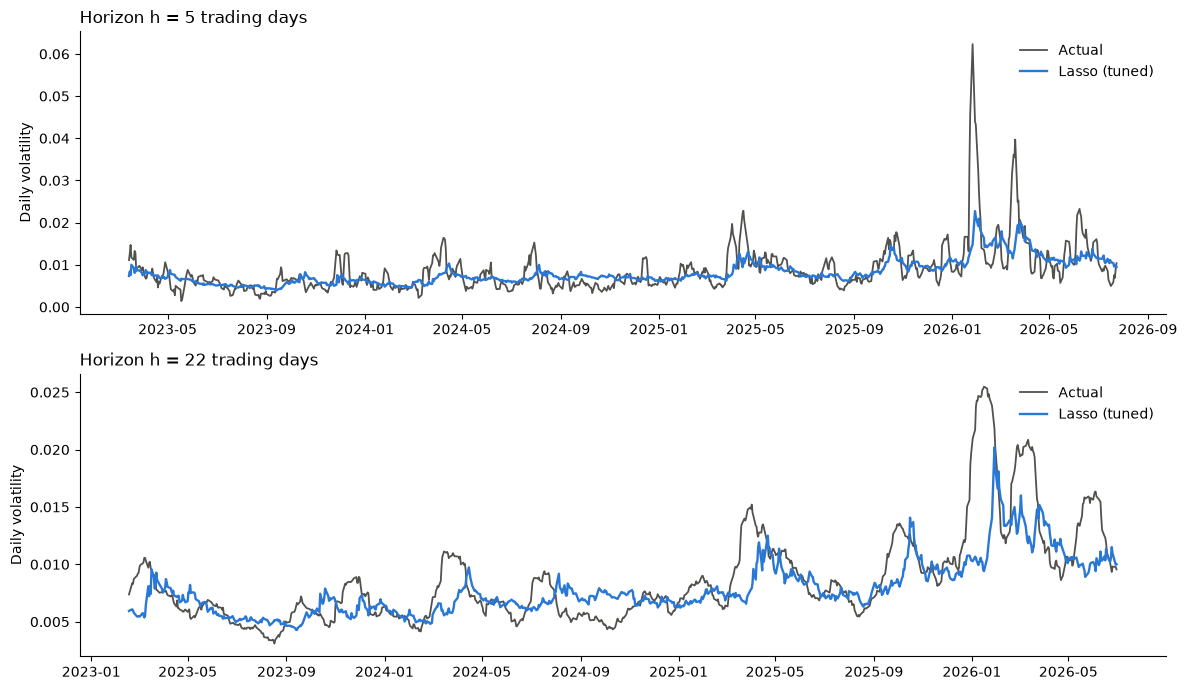

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (te, tgt, preds, hh) in zip(axes, [(test_5, target_5, preds_5, 5),
                                           (test_22, target_22, preds_22, 22)]):
    ax.plot(te.index, np.exp(te[tgt]), color="#52514e", lw=1.3, label="Actual")
    ax.plot(te.index, preds["Lasso (tuned)"], color="#2a78d6", lw=1.7,
            label="Lasso (tuned)")
    ax.set_title(f"Horizon h = {hh} trading days", loc="left")
    ax.set_ylabel("Daily volatility")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
show("lasso_actual_vs_predicted")

### 6.2 Residuals

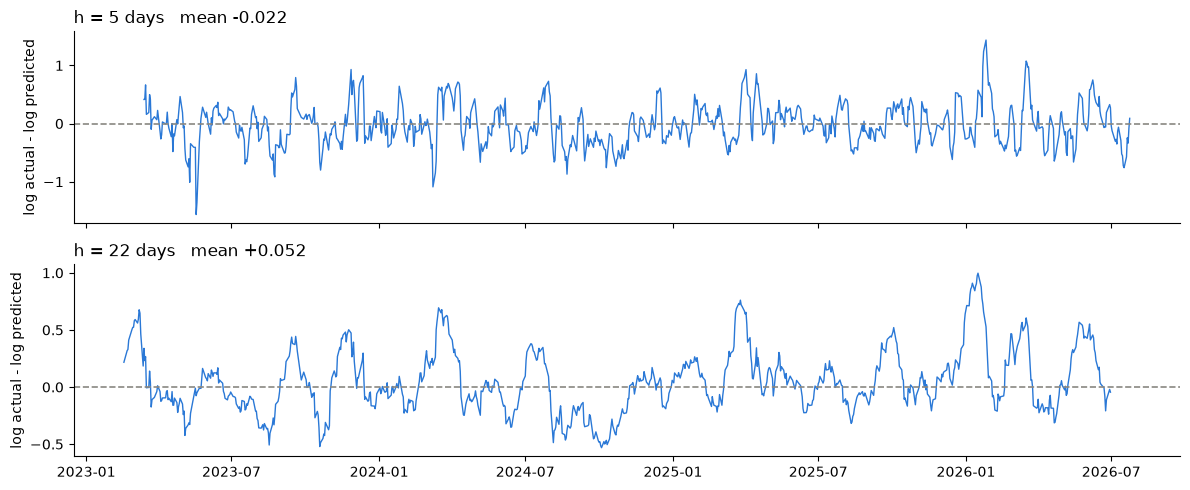

count      mean       std       min       25%       50%       75%       max
5  Actual        807.0  0.008659  0.005495  0.001405  0.005340  0.007259  0.010261  0.062307
   Predicted     807.0  0.008163  0.002910  0.003932  0.006337  0.007296  0.009569  0.022721
   Residual_log  807.0 -0.022170  0.358909 -1.564598 -0.259086 -0.041548  0.192272  1.436277
22 Actual        805.0  0.008713  0.004134  0.003097  0.005855  0.007466  0.010309  0.025481
   Predicted     805.0  0.007861  0.002387  0.004283  0.006310  0.007258  0.008965  0.020185
   Residual_log  805.0  0.052485  0.278990 -0.530613 -0.133702  0.012736  0.210795  0.996965

In [11]:
residual_frames = {}
for hh, te, tgt, preds in ((5, test_5, target_5, preds_5), (22, test_22, target_22, preds_22)):
    residual_frames[hh] = pd.DataFrame({
        "Actual": np.exp(te[tgt].to_numpy()),
        "Predicted": preds["Lasso (tuned)"],
        "Residual_log": te[tgt].to_numpy() - np.log(preds["Lasso (tuned)"]),
    }, index=te.index)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, hh in zip(axes, (5, 22)):
    ax.plot(residual_frames[hh].index, residual_frames[hh]["Residual_log"],
            color="#2a78d6", lw=1)
    ax.axhline(0, color="#898781", ls="--", lw=1.2)
    mean_resid = residual_frames[hh]["Residual_log"].mean()
    ax.set_title(f"h = {hh} days   mean {mean_resid:+.3f}", loc="left")
    ax.set_ylabel("log actual - log predicted")
    ax.spines[["top", "right"]].set_visible(False)
show("lasso_residuals")

pd.concat({hh: residual_frames[hh].describe().T for hh in (5, 22)})

## 7. Statistical Significance (Diebold-Mariano)

Newey-West with `h-1` lags, because overlapping forecast windows autocorrelate
the loss differentials.

In [12]:
def dm_table(preds, te, tgt, horizon):
    actual = np.exp(te[tgt].to_numpy())
    model_loss = qlike_loss(actual, preds["Lasso (tuned)"])
    rows = []
    for name in ("Persistence", "HAR (linear)", "Lasso (default)"):
        stat, pval = diebold_mariano(model_loss, qlike_loss(actual, preds[name]), horizon)
        rows.append({"Horizon": horizon, "Comparison": f"Lasso (tuned) vs {name}",
                     "DM_statistic": stat, "p_value": pval,
                     "Significant_5pct": bool(pval < 0.05)})
    return pd.DataFrame(rows)


dm_all = pd.concat([dm_table(preds_5, test_5, target_5, 5),
                    dm_table(preds_22, test_22, target_22, 22)], ignore_index=True)
dm_all

,Horizon,Comparison,DM_statistic,p_value,Significant_5pct
0,5,Lasso (tuned) vs Persistence,-3.897895,0.000097,True
1,5,Lasso (tuned) vs HAR (linear),-3.189666,0.001424,True
2,5,Lasso (tuned) vs Lasso (default),1.130873,0.258108,False
3,22,Lasso (tuned) vs Persistence,-4.378324,0.000012,True
4,22,Lasso (tuned) vs HAR (linear),-3.295458,0.000983,True
5,22,Lasso (tuned) vs Lasso (default),-1.454981,0.145675,False


### 7.1 Model comparison

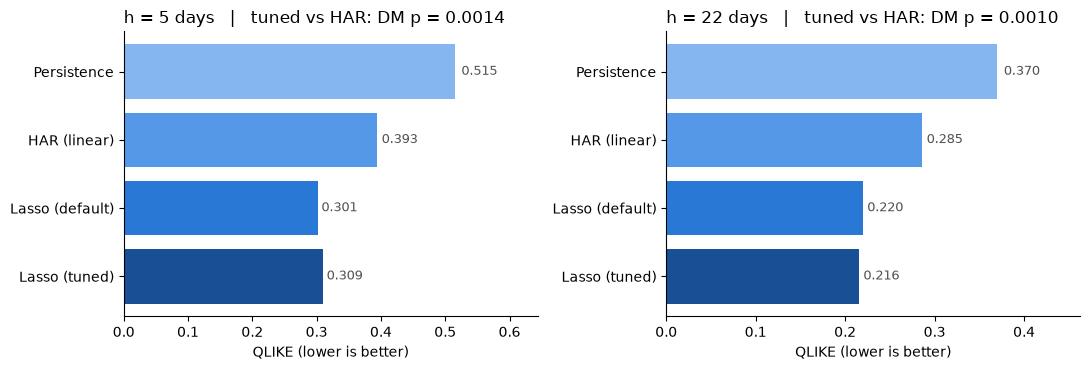

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, hh in zip(axes, (5, 22)):
    sub = all_metrics[all_metrics["Horizon"] == hh]
    p = dm_all[(dm_all.Horizon == hh) &
               (dm_all.Comparison == "Lasso (tuned) vs HAR (linear)")]["p_value"].iloc[0]
    ax.barh(sub["Model"], sub["QLIKE"],
            color=["#86b6ef", "#5598e7", "#2a78d6", "#184f95"])
    for y, v in enumerate(sub["QLIKE"]):
        ax.text(v * 1.02, y, f"{v:.3f}", va="center", fontsize=9, color="#52514e")
    ax.invert_yaxis()
    ax.set_xlim(0, sub["QLIKE"].max() * 1.25)
    ax.set_xlabel("QLIKE (lower is better)")
    ax.set_title(f"h = {hh} days   |   tuned vs HAR: DM p = {p:.4f}", loc="left")
    ax.spines[["top", "right"]].set_visible(False)
show("lasso_model_comparison")

## 8. Feature Importance

Lasso's absolute coefficients on the standardised features -- comparable in
spirit to XGBoost's gain and the LSTM's permutation importance, though not
identical: this reflects each feature's fitted linear weight rather than its
contribution to a tree split or its effect on out-of-sample loss when
shuffled. A coefficient of exactly zero means Lasso's L1 penalty dropped that
feature entirely.

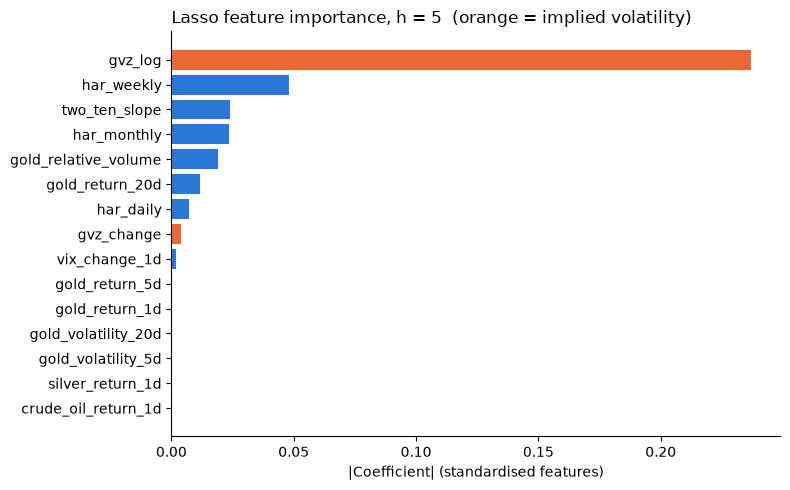

,Feature,Coefficient,Importance
0,gvz_log,0.236901,0.236901
1,har_weekly,0.047962,0.047962
2,two_ten_slope,0.024098,0.024098
3,har_monthly,0.023598,0.023598
4,gold_relative_volume,0.019078,0.019078
5,gold_return_20d,0.011637,0.011637
6,har_daily,0.007214,0.007214
7,gvz_change,0.003799,0.003799
8,vix_change_1d,0.002072,0.002072
9,gold_return_5d,-0.000000,0.000000


In [14]:
importance = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Coefficient": model_5.coef_,
    "Importance": np.abs(model_5.coef_),
}).sort_values("Importance", ascending=False).reset_index(drop=True)

top = importance.head(15).iloc[::-1]
colors = ["#eb6834" if f in IMPLIED_FEATURES else "#2a78d6" for f in top["Feature"]]
plt.figure(figsize=(8, 5))
plt.barh(top["Feature"], top["Importance"], color=colors)
plt.xlabel("|Coefficient| (standardised features)")
plt.title("Lasso feature importance, h = 5  (orange = implied volatility)", loc="left")
plt.gca().spines[["top", "right"]].set_visible(False)
show("lasso_feature_importance")
importance.head(10)

## 9. Ablations

### 9.1 Volatility estimator: Yang-Zhang versus Parkinson

R^2 is not comparable across the two rows because the target differs; the
Diebold-Mariano column is the valid comparison.

In [15]:
estimator_rows = []
for label, prefix in (("Yang-Zhang (overnight gap + intraday)", ""),
                      ("Parkinson (intraday range only)", "park_")):
    har_cols = [prefix + f for f in HAR_FEATURES]
    features = har_cols + MACRO_FEATURES + IMPLIED_FEATURES
    tgt, ref = f"{prefix}vol_target_5d", f"{prefix}vol_current_5d"
    tr, te = make_split(data, features, tgt, ref, 5)

    ba, _ = tune(tr, features, tgt, 5)
    _, _, pred = fit_lasso(tr, te, features, tgt, ba)
    row = score(label, te[tgt], pred, te[ref], 5)

    hp = fit_har(tr, te, tgt, har_cols)
    actual = np.exp(te[tgt].to_numpy())
    stat, pval = diebold_mariano(qlike_loss(actual, np.exp(pred)),
                                 qlike_loss(actual, np.exp(hp)), 5)
    row.update({"DM_vs_HAR": stat, "DM_p_value": pval})
    estimator_rows.append(row)

estimator_ablation = pd.DataFrame(estimator_rows).drop(columns=["Model"])
estimator_ablation.insert(0, "Estimator", [r["Model"] for r in estimator_rows])
estimator_ablation

,Estimator,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy,DM_vs_HAR,DM_p_value
0,Yang-Zhang (overnight gap + intraday),5,0.002477,0.004204,0.473138,0.414153,0.309378,0.700124,-3.189666,0.001424
1,Parkinson (intraday range only),5,0.002173,0.003847,0.426572,0.368362,0.349275,0.682776,-1.692787,0.090496


### 9.2 Feature set

In [16]:
feature_sets = {
    "HAR only": HAR_FEATURES,
    "Macro / cross-asset only": MACRO_FEATURES,
    "HAR + macro (original set)": HAR_FEATURES + MACRO_FEATURES,
    "HAR + implied volatility": HAR_FEATURES + IMPLIED_FEATURES,
    "HAR + macro + implied (full)": ALL_FEATURES,
}

common = data.dropna(subset=ALL_FEATURES + ["vol_target_5d", "vol_current_5d"])
cut = int(len(common) * (1 - TEST_FRACTION))
tr_c, te_c = common.iloc[:cut - 5], common.iloc[cut:]

rows = []
for label, feats in feature_sets.items():
    ba, _ = tune(tr_c, feats, "vol_target_5d", 5)
    _, _, pred = fit_lasso(tr_c, te_c, feats, "vol_target_5d", ba)
    row = score(label, te_c["vol_target_5d"], pred, te_c["vol_current_5d"], 5)
    row["N_features"] = len(feats)
    rows.append(row)

feature_ablation = pd.DataFrame(rows).rename(columns={"Model": "Feature_set"})
feature_ablation[["Feature_set", "N_features", "R2_log", "R2_level", "QLIKE"]]

,Feature_set,N_features,R2_log,R2_level,QLIKE
0,HAR only,3,0.354794,0.288905,0.393255
1,Macro / cross-asset only,21,0.373360,0.233728,0.496380
2,HAR + macro (original set),24,0.420945,0.316739,0.397986
3,HAR + implied volatility,8,0.451073,0.415828,0.303003
4,HAR + macro + implied (full),29,0.473138,0.414153,0.309378


### 9.3 Both ablations

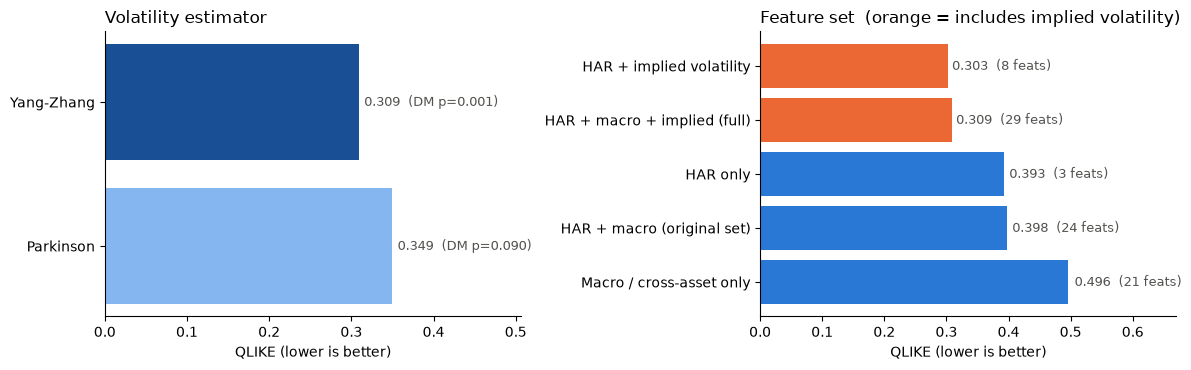

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

est = estimator_ablation.iloc[::-1]
axes[0].barh(est["Estimator"].str.replace(r" \(.*", "", regex=True), est["QLIKE"],
             color=["#86b6ef", "#184f95"])
for y, (v, p) in enumerate(zip(est["QLIKE"], est["DM_p_value"])):
    axes[0].text(v * 1.02, y, f"{v:.3f}  (DM p={p:.3f})", va="center",
                 fontsize=9, color="#52514e")
axes[0].set_xlim(0, est["QLIKE"].max() * 1.45)
axes[0].set_title("Volatility estimator", loc="left")

feat = feature_ablation.sort_values("QLIKE", ascending=False)
axes[1].barh(feat["Feature_set"], feat["QLIKE"],
             color=["#eb6834" if "implied" in f else "#2a78d6" for f in feat["Feature_set"]])
for y, (v, n) in enumerate(zip(feat["QLIKE"], feat["N_features"])):
    axes[1].text(v * 1.02, y, f"{v:.3f}  ({n} feats)", va="center",
                 fontsize=9, color="#52514e")
axes[1].set_xlim(0, feat["QLIKE"].max() * 1.35)
axes[1].set_title("Feature set  (orange = includes implied volatility)", loc="left")

for ax in axes:
    ax.set_xlabel("QLIKE (lower is better)")
    ax.spines[["top", "right"]].set_visible(False)
show("lasso_ablations")

## 10. Volatility-Direction Classifier

Binary framing of the same problem, which supports ROC-AUC and a confusion
matrix. Logistic regression in place of the linear Lasso, on the same
standardised features.

In [18]:
def run_classifier(horizon):
    tgt, ref = f"vol_target_{horizon}d", f"vol_current_{horizon}d"
    frame = data.dropna(subset=ALL_FEATURES + [tgt, ref]).copy()
    frame["label"] = (frame[tgt] > frame[ref]).astype(int)
    cut = int(len(frame) * (1 - TEST_FRACTION))
    tr, te = frame.iloc[:cut - horizon], frame.iloc[cut:]

    scaler = StandardScaler().fit(tr[ALL_FEATURES])
    clf = LogisticRegression(penalty="l1", solver="liblinear", C=1.0,
                              random_state=SEED, max_iter=5000)
    clf.fit(scaler.transform(tr[ALL_FEATURES]), tr["label"])

    y_true = te["label"].to_numpy()
    proba = clf.predict_proba(scaler.transform(te[ALL_FEATURES]))[:, 1]
    y_pred = clf.predict(scaler.transform(te[ALL_FEATURES]))
    metrics = {
        "Horizon": horizon,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Majority_Baseline": max(y_true.mean(), 1 - y_true.mean()),
        "ROC_AUC": roc_auc_score(y_true, proba),
        "PR_AUC": average_precision_score(y_true, proba),
        "F1": f1_score(y_true, y_pred),
        "N_test": len(te),
    }
    return metrics, y_true, proba, y_pred


clf_rows, roc_data = [], {}
for hh in (5, 22):
    m, y_true, proba, y_pred = run_classifier(hh)
    clf_rows.append(m)
    roc_data[hh] = (y_true, proba, y_pred)
clf_metrics = pd.DataFrame(clf_rows)
clf_metrics

,Horizon,Accuracy,Majority_Baseline,ROC_AUC,PR_AUC,F1,N_test
0,5,0.697646,0.503098,0.777434,0.791752,0.668478,807
1,22,0.721739,0.541615,0.856381,0.785335,0.619048,805


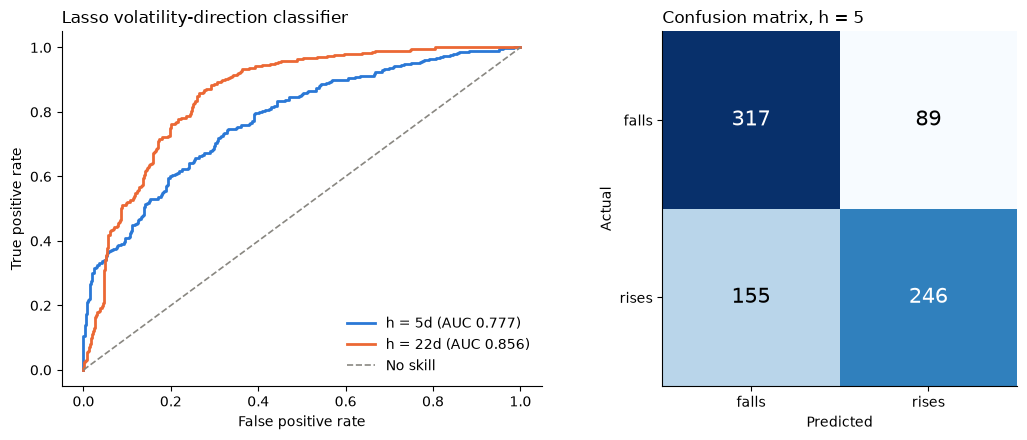

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for hh, color in ((5, "#2a78d6"), (22, "#eb6834")):
    y_true, proba, _ = roc_data[hh]
    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"h = {hh}d (AUC {roc_auc_score(y_true, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="#898781", lw=1.2, label="No skill")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("Lasso volatility-direction classifier", loc="left")
axes[0].legend(frameon=False)

y_true, _, y_pred = roc_data[5]
cm = confusion_matrix(y_true, y_pred)
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1], ["falls", "rises"]); axes[1].set_yticks([0, 1], ["falls", "rises"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion matrix, h = 5", loc="left")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                     color="white" if cm[i, j] > cm.max() * 0.6 else "black")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
show("lasso_direction_roc")

## 11. One-Year Walk-Forward Backtest

Train only on data from before the last year, then walk forward day by day,
refitting on everything that has already resolved. Scored against a 20-day
trailing average, which costs nothing. Lasso is cheap like XGBoost, so this
refits every single day of the window rather than the LSTM notebook's
21-day blocks.

In [20]:
BACKTEST_START = "2025-07-31"
BT_ALPHA = 0.001

bt = data.copy()
bt["y1"] = bt["har_daily"].shift(-1)                  # next-day log volatility
bt["realised"] = np.exp(bt["y1"])
bt["naive"] = bt["gold_return_1d"].rolling(20).std()  # free comparator
bt["gold_next"] = np.expm1(bt["tomorrow_gold_log_return"])
bt = bt.dropna(subset=ALL_FEATURES + ["y1", "gold_next", "naive"])

pre, window = bt.loc[bt.index < BACKTEST_START], bt.loc[BACKTEST_START:]
assert pre.index.max() < window.index.min()
print(f"Train on      {pre.index.min().date()} to {pre.index.max().date()}  ({len(pre)} rows)")
print(f"Walk forward  {window.index.min().date()} to {window.index.max().date()}  ({len(window)} rows)")

records = []
for i, date in enumerate(window.index, 1):
    pos = bt.index.get_loc(date)
    history = bt.iloc[:pos]          # every label here has already resolved
    scaler = StandardScaler().fit(history[ALL_FEATURES])
    model = Lasso(alpha=BT_ALPHA, random_state=SEED, max_iter=50_000)
    model.fit(scaler.transform(history[ALL_FEATURES]), history["y1"])
    bias = smearing(history["y1"] - model.predict(scaler.transform(history[ALL_FEATURES])))
    row = bt.loc[[date]]
    records.append({
        "Date": date,
        "forecast": float(np.exp(model.predict(scaler.transform(row[ALL_FEATURES]))[0] + bias)),
        "naive": float(row["naive"].iloc[0]),
        "realised": float(row["realised"].iloc[0]),
        "gold_next": float(row["gold_next"].iloc[0]),
    })
    if i % 50 == 0:
        print(f"  {i}/{len(window)} days")

wf = pd.DataFrame(records).set_index("Date")
print()
print(f"Forecast R2 on log volatility: "
      f"{r2_score(np.log(wf.realised), np.log(wf.forecast)):+.3f}")
print(f"Model RMSE {np.sqrt(np.mean((wf.realised - wf.forecast) ** 2)):.5f}  "
      f"vs naive 20d {np.sqrt(np.mean((wf.realised - wf.naive) ** 2)):.5f}")

Train on      2008-07-28 to 2025-07-30  (3633 rows)
Walk forward  2025-07-31 to 2026-07-29  (237 rows)


  50/237 days


  100/237 days


  150/237 days


  200/237 days



Forecast R2 on log volatility: +0.162
Model RMSE 0.00822  vs naive 20d 0.01127


### 11.1 Trading the forecast from a $1,000 stake

The forecast cannot pick direction -- returns are not predictable -- but it can
*size* a position: hold more gold when volatility is forecast to be low,
targeting a constant 10% annualised risk. Net of 2bp costs on turnover.

The naive line applies the identical rule to a 20-day trailing average, which
costs nothing. The gap between it and the model line is what the forecast
contributes; the gap to buy-and-hold is mostly the sizing rule itself.

In [21]:
STAKE = 1000.0
COST = 0.0002              # 2 bps of traded notional
TARGET_ANNUAL_VOL = 0.10   # size the position to a constant 10% annual risk
MAX_LEVERAGE = 3.0

equity = pd.DataFrame(index=wf.index)
equity["Gold buy & hold"] = STAKE * (1 + wf["gold_next"]).cumprod()

for label, vol in (("Vol-targeted gold (naive 20d)", wf["naive"]),
                   ("Vol-targeted gold (Lasso)", wf["forecast"])):
    weight = (TARGET_ANNUAL_VOL / np.sqrt(252) / vol).clip(0, MAX_LEVERAGE)
    turnover = np.abs(np.diff(np.r_[0.0, weight]))
    equity[label] = STAKE * (1 + weight * wf["gold_next"] - turnover * COST).cumprod()

summary = pd.DataFrame([{
    "Strategy": name,
    "Final $": curve.iloc[-1],
    "Profit $": curve.iloc[-1] - STAKE,
    "Return %": 100 * (curve.iloc[-1] / STAKE - 1),
    "Sharpe": np.sqrt(252) * curve.pct_change().mean() / curve.pct_change().std(),
    "Max DD %": 100 * (curve / curve.cummax() - 1).min(),
} for name, curve in equity.items()])
summary

,Strategy,Final $,Profit $,Return %,Sharpe,Max DD %
0,Gold buy & hold,1097.082939,97.082939,9.708294,0.430403,-27.466656
1,Vol-targeted gold (naive 20d),1091.246872,91.246872,9.124687,0.697769,-14.906707
2,Vol-targeted gold (Lasso),1163.732046,163.732046,16.373205,1.144867,-16.058017


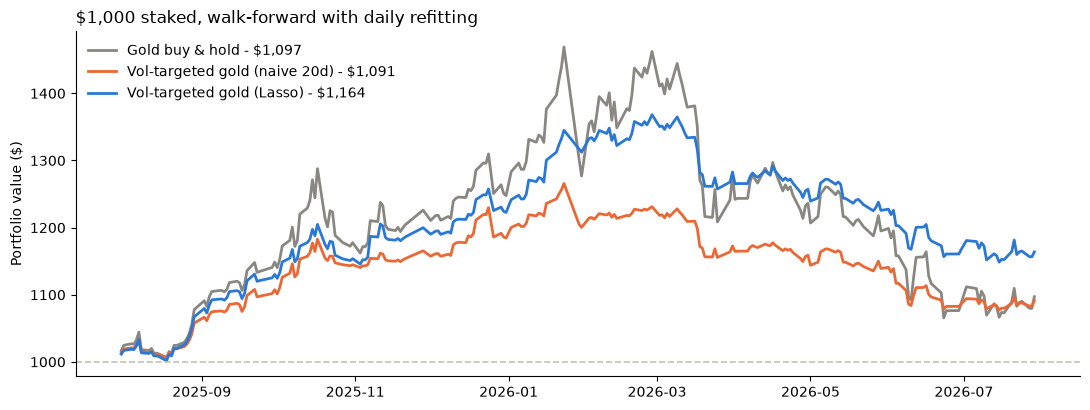

In [22]:
series = [("Gold buy & hold", "#898781"),
          ("Vol-targeted gold (naive 20d)", "#eb6834"),
          ("Vol-targeted gold (Lasso)", "#2a78d6")]

plt.figure(figsize=(11, 4.2))
for name, color in series:
    plt.plot(equity.index, equity[name], color=color, lw=2,
             label=f"{name} - ${equity[name].iloc[-1]:,.0f}")
plt.axhline(STAKE, color="#c3c2b7", ls="--", lw=1.2)
plt.ylabel("Portfolio value ($)")
plt.title("$1,000 staked, walk-forward with daily refitting", loc="left")
plt.legend(frameon=False, loc="upper left")
plt.gca().spines[["top", "right"]].set_visible(False)
show("lasso_backtest_equity")

## 12. Export Results

Written under a `lasso_vol_` prefix. The old `lasso_metrics.csv`,
`lasso_predictions.csv`, and `lasso_feature_importance.csv` belong to the
return model and are left in place.

In [23]:
from pathlib import Path

RESULTS_DIR = "results"
out = Path(RESULTS_DIR)
out.mkdir(parents=True, exist_ok=True)

all_metrics.to_csv(out / "lasso_vol_metrics.csv", index=False)
dm_all.to_csv(out / "lasso_vol_dm_tests.csv", index=False)
tuning_log.to_csv(out / "lasso_vol_tuning_results.csv", index=False)
importance.to_csv(out / "lasso_vol_feature_importance.csv", index=False)
feature_ablation.to_csv(out / "lasso_vol_feature_ablation.csv", index=False)
estimator_ablation.to_csv(out / "lasso_vol_estimator_ablation.csv", index=False)
clf_metrics.to_csv(out / "lasso_vol_direction_metrics.csv", index=False)
summary.to_csv(out / "lasso_vol_backtest_summary.csv", index=False)

predictions_export = pd.concat([
    pd.DataFrame({"Date": test_5.index, "Horizon": 5,
                  "Actual_Volatility": np.exp(test_5[target_5].to_numpy()),
                  "Persistence": preds_5["Persistence"],
                  "HAR": preds_5["HAR (linear)"],
                  "Lasso_Default": preds_5["Lasso (default)"],
                  "Lasso_Tuned": preds_5["Lasso (tuned)"]}),
    pd.DataFrame({"Date": test_22.index, "Horizon": 22,
                  "Actual_Volatility": np.exp(test_22[target_22].to_numpy()),
                  "Persistence": preds_22["Persistence"],
                  "HAR": preds_22["HAR (linear)"],
                  "Lasso_Default": preds_22["Lasso (default)"],
                  "Lasso_Tuned": preds_22["Lasso (tuned)"]}),
], ignore_index=True)
predictions_export.to_csv(out / "lasso_vol_predictions.csv", index=False)

wf.to_csv(out / "lasso_vol_walkforward.csv")

for path in sorted(out.glob("lasso_vol_*.csv")):
    print(path)

results\lasso_vol_backtest_summary.csv
results\lasso_vol_direction_metrics.csv
results\lasso_vol_dm_tests.csv
results\lasso_vol_estimator_ablation.csv
results\lasso_vol_feature_ablation.csv
results\lasso_vol_feature_importance.csv
results\lasso_vol_metrics.csv
results\lasso_vol_predictions.csv
results\lasso_vol_tuning_results.csv
results\lasso_vol_walkforward.csv


### 12.1 Summary

In [24]:
tuned = all_metrics[all_metrics["Model"] == "Lasso (tuned)"].set_index("Horizon")
har = all_metrics[all_metrics["Model"] == "HAR (linear)"].set_index("Horizon")

for hh in (5, 22):
    p = dm_all[(dm_all.Horizon == hh) &
               (dm_all.Comparison == "Lasso (tuned) vs HAR (linear)")]["p_value"].iloc[0]
    verdict = "significant" if p < 0.05 else "not significant at 5%"
    qlike_val = tuned.loc[hh, "QLIKE"]
    har_qlike = har.loc[hh, "QLIKE"]
    r2_val = tuned.loc[hh, "R2_log"]
    dir_acc = tuned.loc[hh, "Directional_Accuracy"]
    print(f"h = {hh:>2}d   Lasso QLIKE {qlike_val:.3f}  "
          f"vs HAR {har_qlike:.3f}   "
          f"R2(log) {r2_val:.3f}   "
          f"dir. acc. {dir_acc:.1%}   "
          f"DM p={p:.4f} ({verdict})")

h =  5d   Lasso QLIKE 0.309  vs HAR 0.393   R2(log) 0.473   dir. acc. 70.0%   DM p=0.0014 (significant)
h = 22d   Lasso QLIKE 0.216  vs HAR 0.285   R2(log) 0.521   dir. acc. 77.5%   DM p=0.0010 (significant)


Lasso is now answering the same question as XGBoost and the LSTM -- how
volatile will gold be over the next week or month -- on the same sample,
against the same benchmarks, under the same loss. Read all three notebooks
side by side: the comparison that matters is each tuned model against the HAR
benchmark, which is the bar a forecast has to clear before it is worth
anything, and then the three tuned models against each other.